In [2]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
from tqdm import tqdm

In [3]:
import ROOT as r
import warnings
warnings.filterwarnings('ignore')

In [4]:
r.gSystem.Load('$EVNDISPSYS/lib/libVAnaSum.so')

0

In [5]:
# 822000 has 5000 muons

In [6]:
wobbles = ('0', '0.5', '1', '1.5', '2')
sim_muon_params_per_wobble = []

for w in tqdm(wobbles):

    filename = '/raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/822000_w' + w + '.root'
    sim = r.TFile(filename)
    params = sim.Get('Tel_2/tpars')

    num_events = 0
    for event in params:
        if event.muonValid and event.muonRadius:
            num_events += 1

    sim_muon_params = np.zeros((8, num_events))
    i = 0

    for event in params:
        if event.muonValid and event.muonRadius:
            sim_muon_params[0][i] = event.muonX0
            sim_muon_params[1][i] = event.muonY0
            sim_muon_params[2][i] = event.muonXC
            sim_muon_params[3][i] = event.muonYC
            sim_muon_params[4][i] = event.muonRadius
            sim_muon_params[5][i] = event.muonRSigma
            sim_muon_params[6][i] = event.muonSize
            sim_muon_params[7][i] = event.muonIPCorrectedSize
            i += 1

    sim_muon_params_per_wobble.append(sim_muon_params)

100%|██████████| 5/5 [00:02<00:00,  2.41it/s]


In [7]:
for i, w in enumerate(wobbles):
    output = 'sim_data/muons_822000_w' + w + '.csv'
    np.savetxt(output, sim_muon_params_per_wobble[i].T, delimiter=',')

In [19]:
# sims = 'sim_data/muons_820800.csv'
# muon_radii, muon_radii_err, muon_sizes = np.loadtxt(sims, delimiter=',', unpack=True)

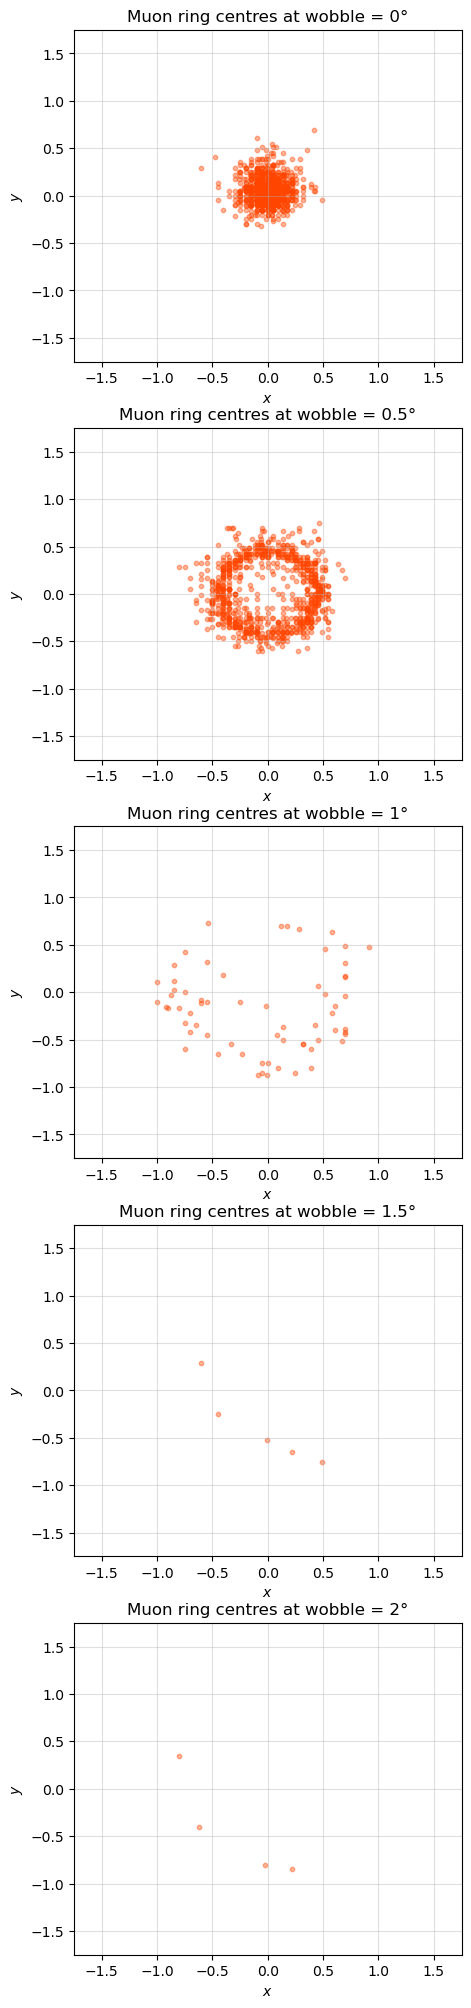

In [8]:
plt.figure(figsize=(5, 25))

for i, w in enumerate(wobbles):
    positions = sim_muon_params_per_wobble[i][:2]

    plt.subplot(5, 1, i+1)

    plt.scatter(positions[0], positions[1], c='orangered', marker='o', s=10, alpha=0.4)

    plt.xlim(-1.75, 1.75)
    plt.ylim(-1.75, 1.75)

    plt.grid(alpha=0.4)
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
    plt.title('Muon ring centres at wobble = ' + w + '°')

plt.show()

In [9]:
def get_impact_factor(xi):

    rel_intensity_per_az = lambda phi, xi: np.sqrt(1 - xi**2 * np.sin(phi)**2)

    if xi > 1:
        bound = np.arcsin(1/xi)
    else:
        bound = np.pi/2
    
    integ = quad(rel_intensity_per_az, 0, bound, args=(xi))[0]
    return integ * 2 / np.pi

In [10]:
def get_distance(x1, y1, x2, y2):
    square = (x2-x1) ** 2 + (y2-y1) ** 2
    return np.sqrt(square)

In [28]:
xis = np.linspace(0, 50, 10000)
Fs = np.zeros_like(xis)

for i, xi in enumerate(xis):
    Fs[i] = get_impact_factor(xi)

func_1 = CubicSpline(Fs[::-1], xis[::-1])
func_2 = CubicSpline(xis / Fs, xis)

In [29]:
sim_muons_w0_prams = sim_muon_params_per_wobble[0]

In [30]:
distances = get_distance(*sim_muons_w0_prams[:4])
radii = sim_muons_w0_prams[4]
evndisp_Fs = sim_muons_w0_prams[6] / sim_muons_w0_prams[7]
evndisp_xis = func_1(evndisp_Fs)

In [32]:
calc_xis = func_2(2 * distances / radii)
calc_Fs = np.zeros_like(calc_xis)

for i, xi in enumerate(calc_xis):
    calc_Fs[i] = get_impact_factor(xi)

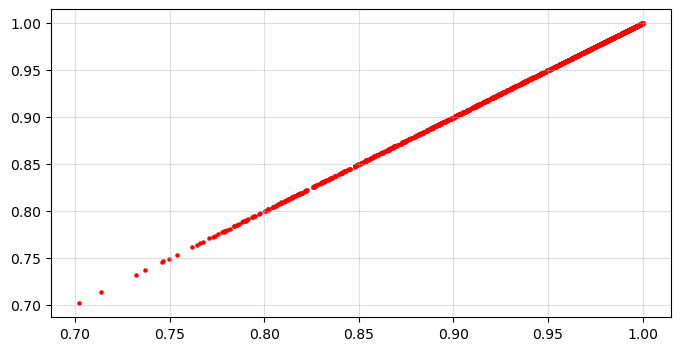

In [34]:
plt.figure(figsize=(8, 4))

plt.scatter(evndisp_Fs, calc_Fs, c='red', marker='o', s=5)

plt.grid(alpha=0.4)
plt.show()

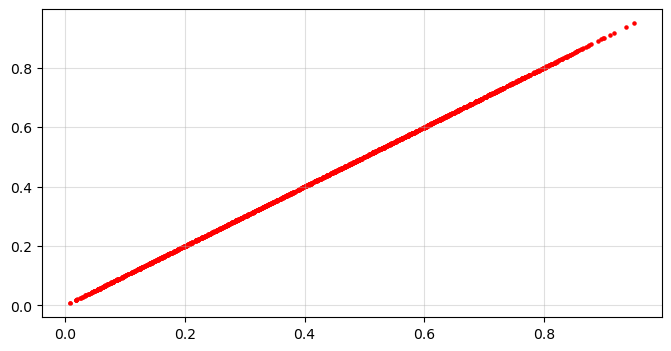

In [33]:
plt.figure(figsize=(8, 4))

plt.scatter(evndisp_xis, calc_xis, c='red', marker='o', s=5)

plt.grid(alpha=0.4)
plt.show()

In [35]:
for params in sim_muon_params_per_wobble:
    print(len(params[4]))

1595
890
64
5
4


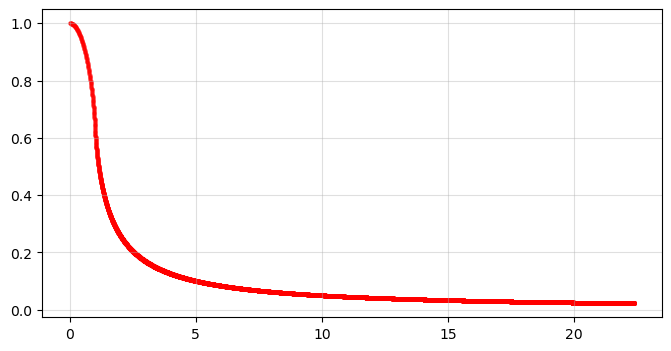

In [19]:
xs = np.linspace(0, 1000, 100000)
ys = func(xs)


plt.figure(figsize=(8, 4))

plt.scatter(ys, ys/xs, c='red', marker='o', s=5, alpha=0.4)

plt.grid(alpha=0.4)
plt.show()
